1) Data exploration
Here is the Kaggle link to the dataset : https://www.kaggle.com/datasets/tarique7/daily-crude-price-dataset

In [2]:
# libraries import for this project
import pandas as pd
import numpy as np
import matplotlib. pyplot as plt
import matplotlib. dates as mdates
import seaborn as sns
from scipy. stats import norm
from statsmodels. tsa. stattools import adfuller, kpss
from statsmodels. tsa. seasonal import seasonal_decompose
from statsmodels. graphics. tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels. tsa. holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error
from statsmodels. tsa. statespace. sarimax import SARIMAX
from statsmodels. tsa. arima. model import ARIMA
from statsmodels. tsa. stattools import arma_order_select_ic
from sklearn. model_selection import TimeSeriesSplit
from sklearn. preprocessing import MinMaxScaler
from itertools import product
from math import sqrt
from darts. timeseries import TimeSeries
from darts. utils. timeseries_generation import datetime_attribute_timeseries
from darts. dataprocessing. transformers import Scaler
from darts. models import RNNModel, NBEATSModel
from pandas.tseries.offsets import Day, BDay
import kagglehub


C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [ ]:
# dataset import
path = kagglehub.dataset_download("tarique7/daily-crude-price-dataset")

print("Path to dataset files:", path)



100%|██████████| 83.7k/83.7k [00:00<00:00, 547kB/s]

Extracting files...
Path to dataset files: C:\Users\alexi\.cache\kagglehub\datasets\tarique7\daily-crude-price-dataset\versions\2


In [8]:
#changing the path to the csv file
path = "./data/Crude_oil_data.csv"

# loading the dataset
df = pd. read_csv(path)

#dataset exploration
print(df.info())


#Found 11 missing values in the "Vol." column, we will take the mean of the column on a 30-day window to fill these missing values
def convert_volume(vol):
    if pd.isna(vol):
        return np.nan
    if isinstance(vol, str):
        vol = vol.upper().replace('K', 'e3').replace('M', 'e6').replace('B', 'e9')
        try:
            return float(vol)
        except ValueError:
            return np.nan
    return float(vol)

df['Vol.'] = df['Vol.'].apply(convert_volume)

#converting the "Date" column to datetime format
df['Date'] = pd. to_datetime(df['Date'], format='%m/%d/%Y')

#Setting the "Date" column as the index of the dataframe
df = df. set_index('Date')
df = df.sort_index()

df['Vol.'] = df['Vol.'].fillna(df['Vol.'].rolling(window=30, min_periods=1).mean())

#dropping the "Change %" column since it is not useful for our analysis
df = df.drop(columns=['Change %'])

df = df.asfreq('D').ffill()

print(df.info())






<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5000 non-null   object 
 1   Price     5000 non-null   float64
 2   Open      5000 non-null   float64
 3   High      5000 non-null   float64
 4   Low       5000 non-null   float64
 5   Vol.      4989 non-null   object 
 6   Change %  5000 non-null   object 
dtypes: float64(4), object(3)
memory usage: 273.6+ KB
None
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7280 entries, 1987-01-08 to 2006-12-13
Freq: D
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   7280 non-null   float64
 1   Open    7280 non-null   float64
 2   High    7280 non-null   float64
 3   Low     7280 non-null   float64
 4   Vol.    7280 non-null   float64
dtypes: float64(5)
memory usage: 341.2 KB
None


The data are now clean, filling the na found in the volume column with a 30-days window volume mean. Also the date is in datetime format and set as the index of the dataset to make the analysis easier.

Now lets focus on visualisation with a time plot, a volatility analysis and ACF PACF charts to detect saisonality.

We shall recall first the volatility formula : $$\sigma = \sqrt{\frac{1}{n-1} \sum_{t=1}^{n} (r_t - \bar{r})^2}$$

Were r represent the daily yield : $$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$ 





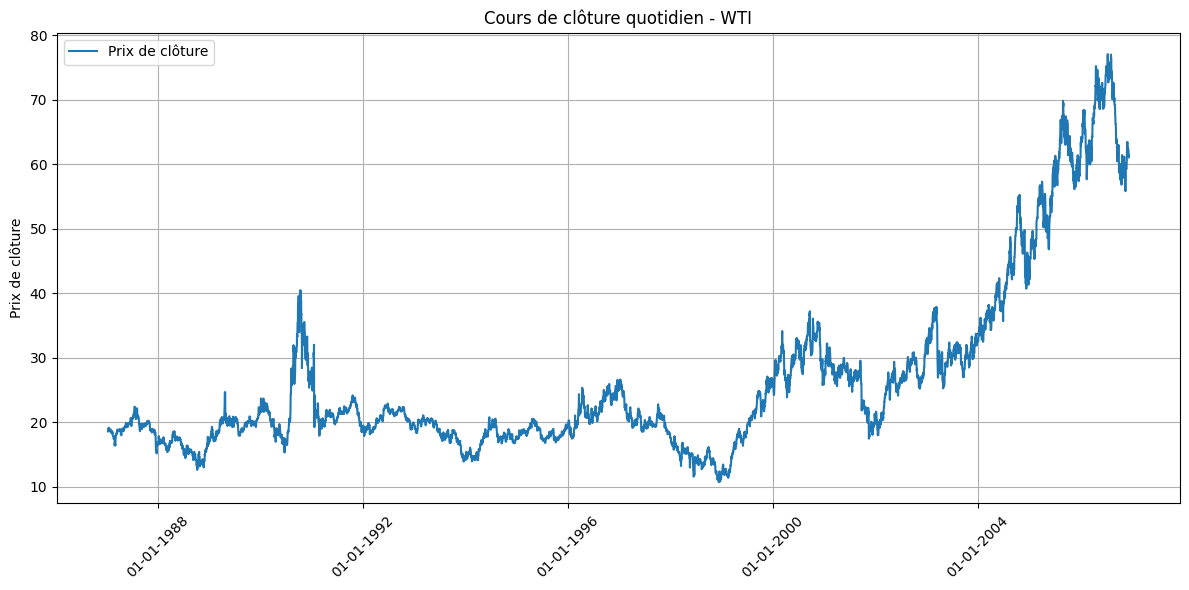

ADF Statistic: -0.422361
p-value: 0.906298
Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


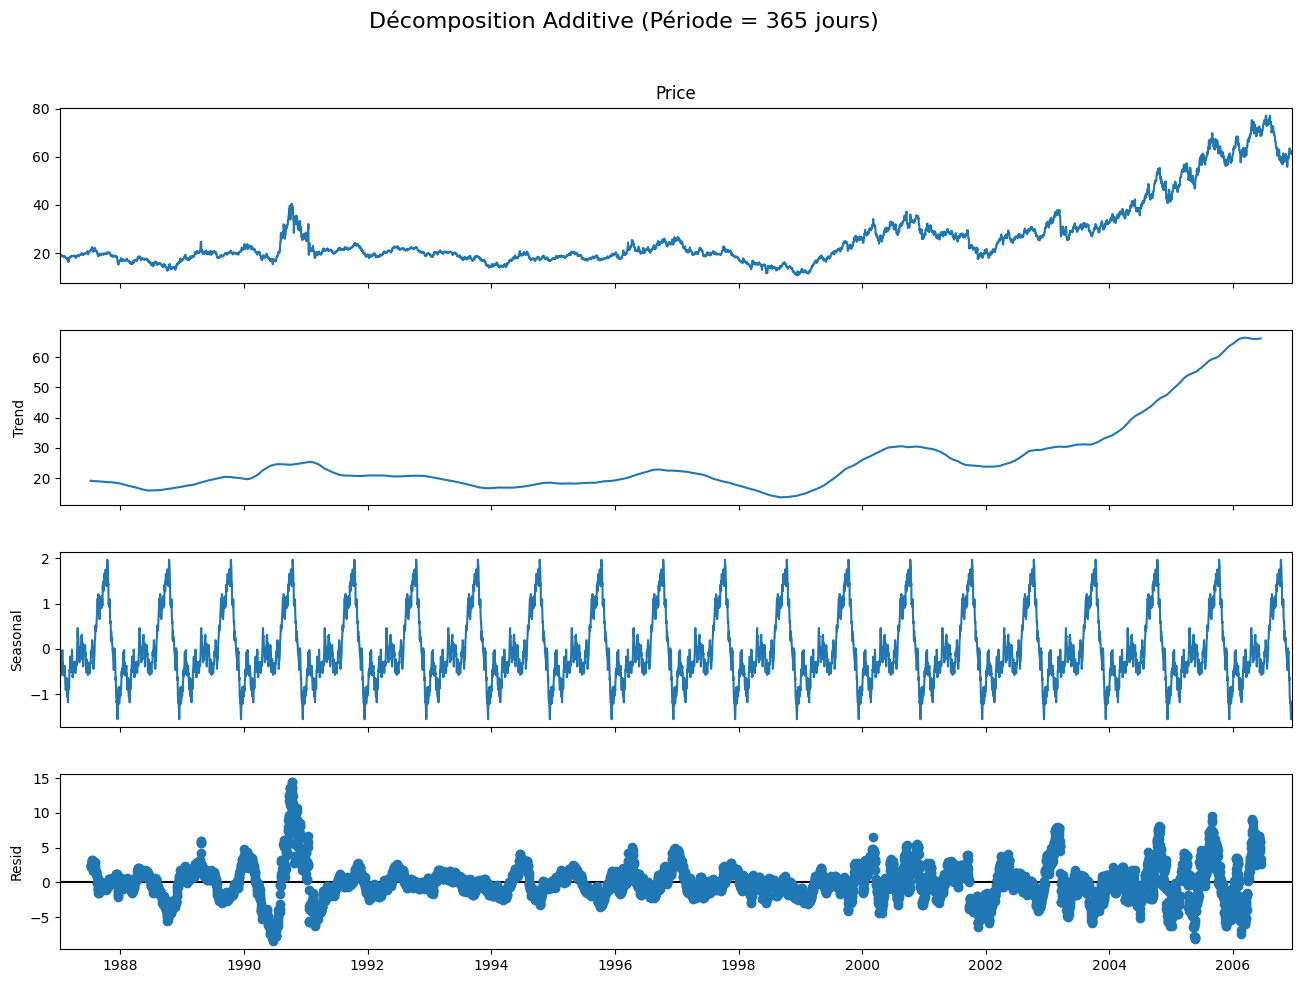

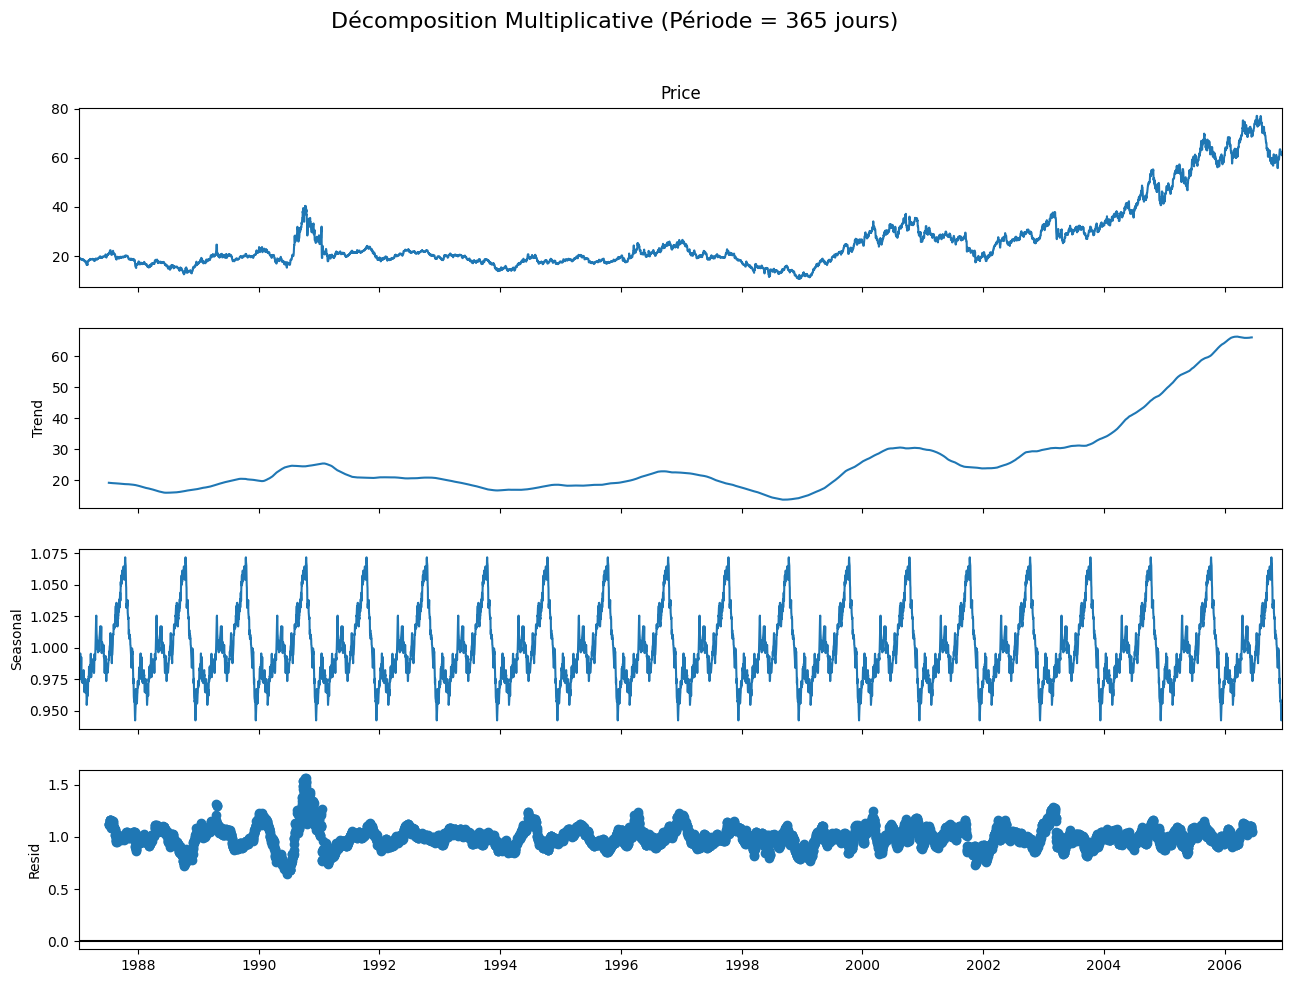

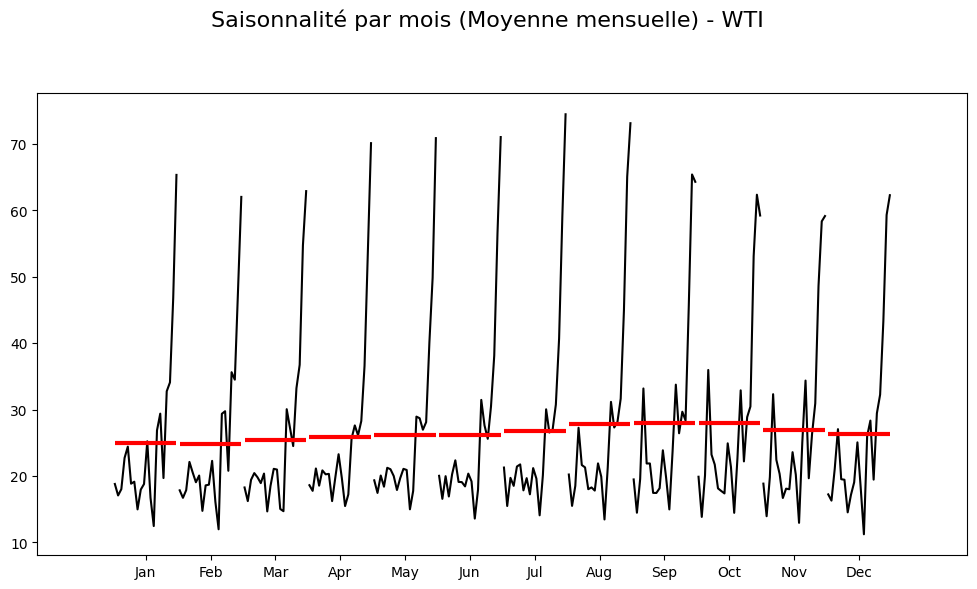

<Figure size 1200x500 with 0 Axes>

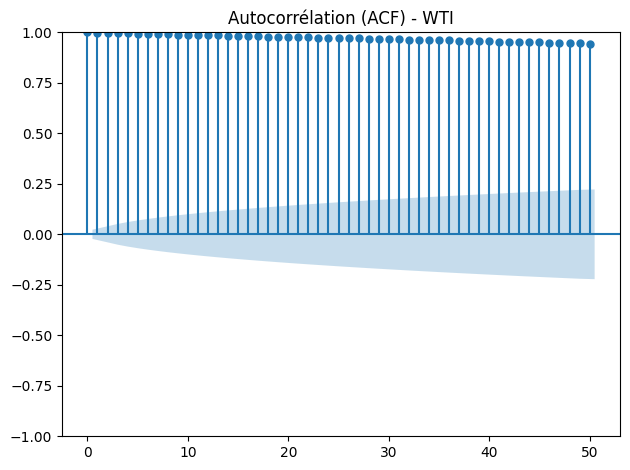

<Figure size 1200x500 with 0 Axes>

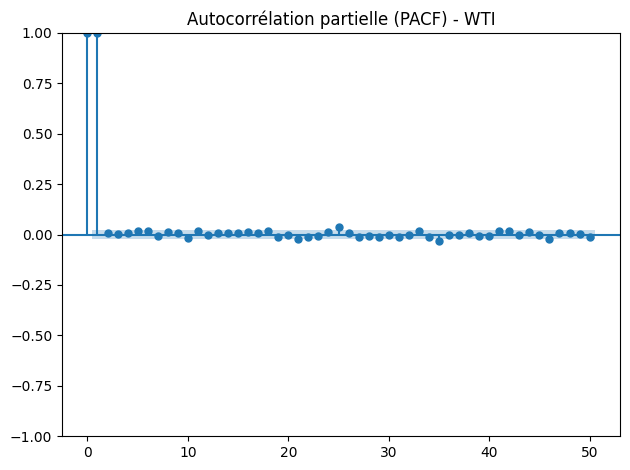

In [10]:
TICKER = "WTI"
# Crude oil price visualisation 
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Price'], label='Prix de clôture')
# Formatage de l'axe des x
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
plt.xticks(rotation=45)
plt.ylabel("Prix de clôture")
plt.title(f"Cours de clôture quotidien - {TICKER}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#Augmented Dickey-Fuller test
result = adfuller(df['Price'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

# Additive seasonal decomposition
model = 'additive'
period = 365  # Période de saisonnalité (1 an)
result = seasonal_decompose(df['Price'], model=model, period=period)
fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle(f"Décomposition {model.capitalize()} (Période = {period} jours)", fontsize=16, y=1.02)
plt.show()

# Multiplicative seasonal decomposition
result = seasonal_decompose(df['Price'], model='multiplicative', period=period)
fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle(f"Décomposition Multiplicative (Période = {period} jours)", fontsize=16, y=1.02)
plt.show()

# Month Seasonality
monthly_series = df['Price'].resample('MS').mean()
fig = month_plot(monthly_series)
fig.set_size_inches(12, 6)
plt.suptitle(f"Saisonnalité par mois (Moyenne mensuelle) - {TICKER}", fontsize=16, y=1.02)
plt.show()


# Autocorrelation
plt.figure(figsize=(12, 5))
plot_acf(df['Price'], lags=50)
plt.title(f"Autocorrélation (ACF) - {TICKER}")
plt.tight_layout()
plt.show()

# Partial Autocorrelation
plt.figure(figsize=(12, 5))
plot_pacf(df['Price'], lags=50)
plt.title(f"Autocorrélation partielle (PACF) - {TICKER}")
plt.tight_layout()
plt.show()


Let's talk about these analysis results. First, with a p-value of approximatively 0.9, the H0 hypothesis of ADF tets is validated witch tells us that the price is not stationary so it depends on time and can follow a mathematical model witch is not a linear function. Looking at the additive and multiplicative decomposition, we can see that the price overall follows an up trend with a boom in 1998 and 2004. The resid of those decomposition is approximatively around 0 or 1 excluding 1991 witch means the unpredictible events are overall limited and a model can be applied to the price. However, the Partial and autocorelation charts tells us that the price is only corelated to the day before with no saisonality climax visible. This is confirmed by the monthly saisonality graph witch shows a high volatility but no real saisonality. 

2) SARIMAX

As the ADF H0 hyposthesis is approuved, we can modelize the price with SARIMAX model, we still need to find the model parameters.

As the price is really volatile over time, we will use the log_price to go further on the analysis.

To train our model, we will use 70% of the dataset (1986-2000) and 30% to test (2000-2006)

In [11]:
df['log_price'] = np.log(df['Price'])
series = df['log_price'].copy()

#Cut date 2 months before the start of the test set
off = pd. Timestamp("2000-09-27")

train = series.loc[:off-pd.Timedelta(days=1)]
test = series.loc[off:]

print(f"train period: {train.index.min()} to {train.index.max()}")
print(f"test period: {test.index.min()} to {test.index.max()}")

train period: 1987-01-08 00:00:00 to 2000-09-26 00:00:00
test period: 2000-09-27 00:00:00 to 2006-12-13 00:00:00
